# Experiment No. 5
## Support Vector Machine (SVM) for Classification

### Aim
To practically implement and understand the Support Vector Machine (SVM) algorithm for classification using the Pulsar Star dataset.

### Objectives
- Understand the working principle of SVM.
- Implement Linear and Non-Linear SVM classifiers.
- Perform data preprocessing and feature scaling.
- Evaluate SVM using classification metrics.
- Compare different kernel functions.
- Optimize SVM hyperparameters using GridSearchCV.
- Visualize the classification performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Load Dataset

In [2]:
file_path = r"C:\Users\SWARA\Downloads\TY\Sem 5\ML Lab\Dataset\pulsar star\pulsar_stars.csv"

data = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", data.shape)

Dataset loaded successfully.
Shape: (17898, 9)


# Dataset Overview

In [3]:
print("First five records:")
display(data.head())

print("\nLast five records:")
display(data.tail())

print("\nDataset dimensions:", data.shape)

First five records:


,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0



Last five records:


,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
17893,136.429688,59.847421,-0.187846,-0.738123,1.296823,12.166062,15.450260,285.931022,0
17894,122.554688,49.485605,0.127978,0.323061,16.409699,44.626893,2.945244,8.297092,0
17895,119.335938,59.935939,0.159363,-0.743025,21.430602,58.872000,2.499517,4.595173,0
17896,114.507812,53.902400,0.201161,-0.024789,1.946488,13.381731,10.007967,134.238910,0
17897,57.062500,85.797340,1.406391,0.089520,188.306020,64.712562,-1.597527,1.429475,0



Dataset dimensions: (17898, 9)


# Dataset information

In [4]:
print("Dataset Information:\n")
data.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                17898 non-null  float64
 1    Standard deviation of the integrated profile  17898 non-null  float64
 2    Excess kurtosis of the integrated profile     17898 non-null  float64
 3    Skewness of the integrated profile            17898 non-null  float64
 4    Mean of the DM-SNR curve                      17898 non-null  float64
 5    Standard deviation of the DM-SNR curve        17898 non-null  float64
 6    Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7    Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                   17898 non-null  int64  
dtypes: float64(8), int64(1)
memor

In [5]:
display(data.describe().T)

,count,mean,std,min,25%,50%,75%,max
Mean of the integrated profile,17898.0,111.079968,25.652935,5.812500,100.929688,115.078125,127.085938,192.617188
Standard deviation of the integrated profile,17898.0,46.549532,6.843189,24.772042,42.376018,46.947479,51.023202,98.778911
Excess kurtosis of the integrated profile,17898.0,0.477857,1.064040,-1.876011,0.027098,0.223240,0.473325,8.069522
Skewness of the integrated profile,17898.0,1.770279,6.167913,-1.791886,-0.188572,0.198710,0.927783,68.101622
Mean of the DM-SNR curve,17898.0,12.614400,29.472897,0.213211,1.923077,2.801839,5.464256,223.392141
Standard deviation of the DM-SNR curve,17898.0,26.326515,19.470572,7.370432,14.437332,18.461316,28.428104,110.642211
Excess kurtosis of the DM-SNR curve,17898.0,8.303556,4.506092,-3.139270,5.781506,8.433515,10.702959,34.539844
Skewness of the DM-SNR curve,17898.0,104.857709,106.514540,-1.976976,34.960504,83.064556,139.309330,1191.000837
target_class,17898.0,0.091574,0.288432,0.000000,0.000000,0.000000,0.000000,1.000000


# Missing Values

In [6]:
missing_values = data.isnull().sum()

print("Missing values in each column:")
display(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:


 Mean of the integrated profile                  0
 Standard deviation of the integrated profile    0
 Excess kurtosis of the integrated profile       0
 Skewness of the integrated profile              0
 Mean of the DM-SNR curve                        0
 Standard deviation of the DM-SNR curve          0
 Excess kurtosis of the DM-SNR curve             0
 Skewness of the DM-SNR curve                    0
target_class                                     0
dtype: int64


Total missing values: 0


# Duplicate Records

In [7]:
duplicate_count = data.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


# Target Distribution

In [8]:
target_column = "target_class"

print("Target classes:")
print(data[target_column].value_counts())

print("\nTarget proportions:")
print(data[target_column].value_counts(normalize=True))

Target classes:
target_class
0    16259
1     1639
Name: count, dtype: int64

Target proportions:
target_class
0    0.908426
1    0.091574
Name: proportion, dtype: float64


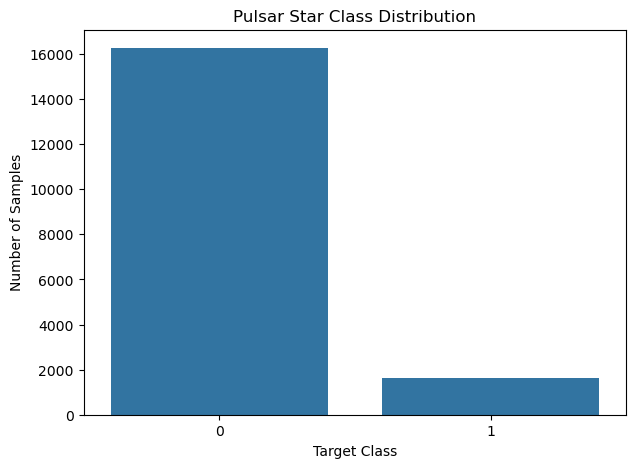

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=target_column,
    data=data
)

plt.title("Pulsar Star Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.show()

# Class Imbalance

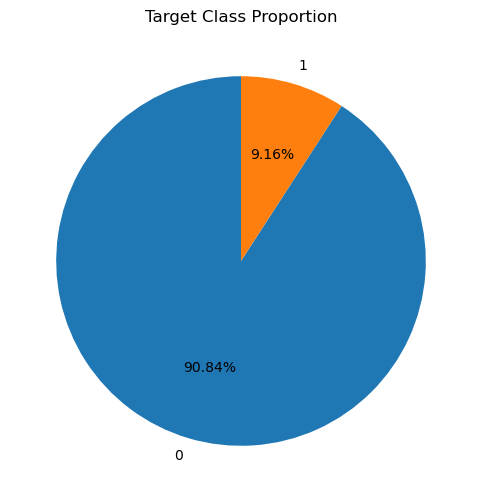

In [10]:
class_counts = data[target_column].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Target Class Proportion")
plt.show()

# Feature Analysis

In [13]:
feature_columns = data.drop(columns=[target_column]).columns

print("Number of features:", len(feature_columns))
print("\nFeatures:")
for feature in feature_columns:
    print(feature)

Number of features: 8

Features:
 Mean of the integrated profile
 Standard deviation of the integrated profile
 Excess kurtosis of the integrated profile
 Skewness of the integrated profile
 Mean of the DM-SNR curve
 Standard deviation of the DM-SNR curve
 Excess kurtosis of the DM-SNR curve
 Skewness of the DM-SNR curve


# Feature Distribution

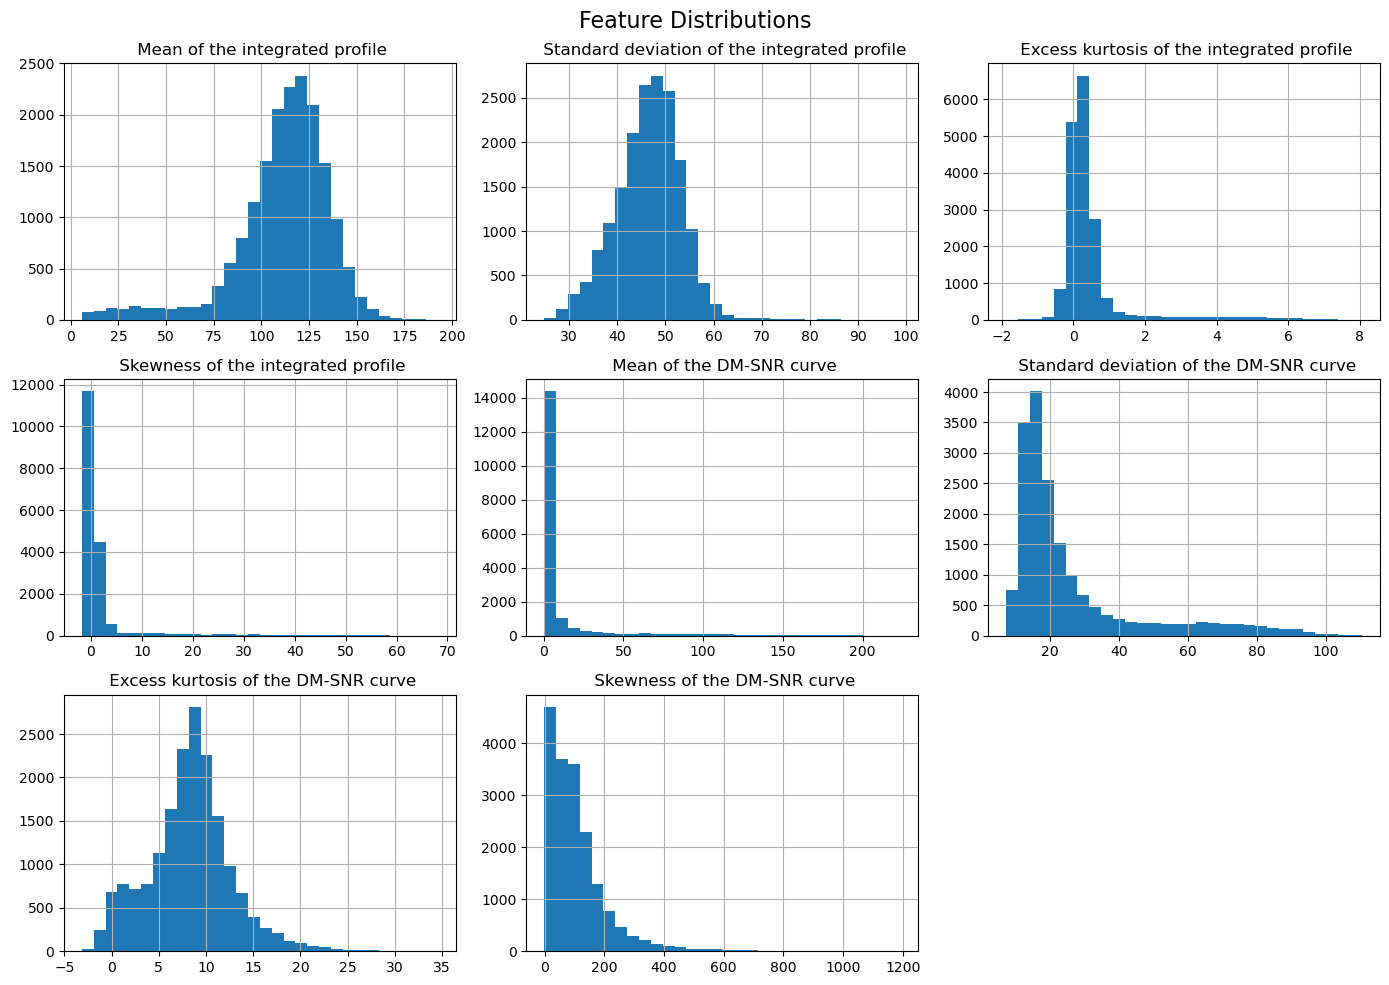

In [14]:
data[feature_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

# Correlation Analysis

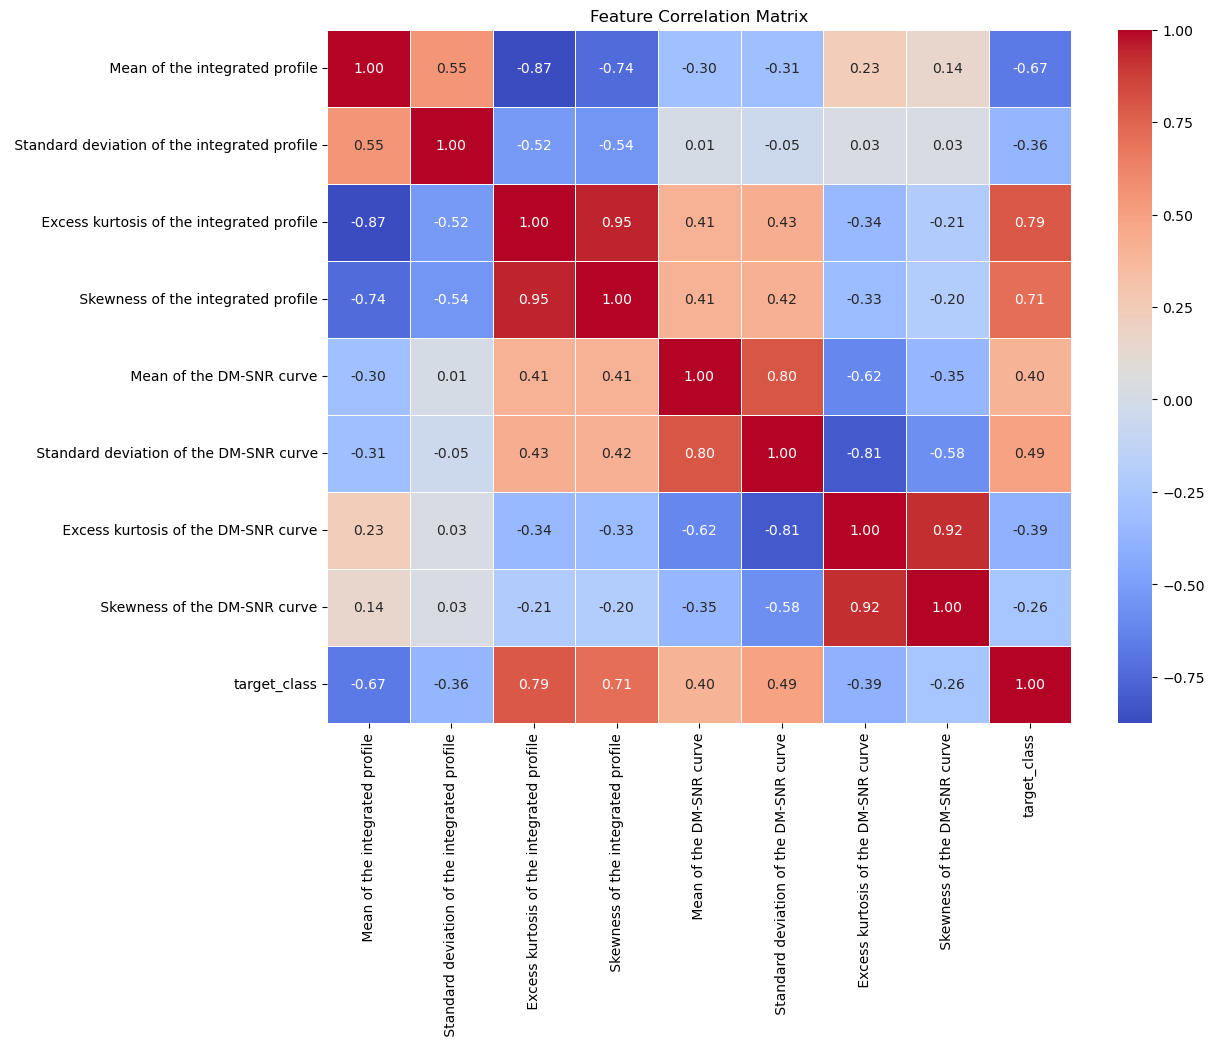

In [15]:
correlation_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

# Feature vs Target Analysis

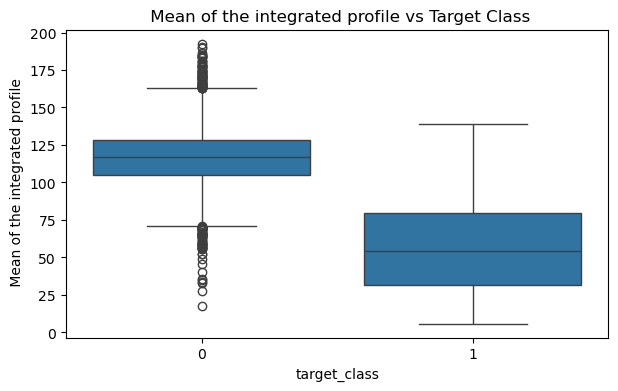

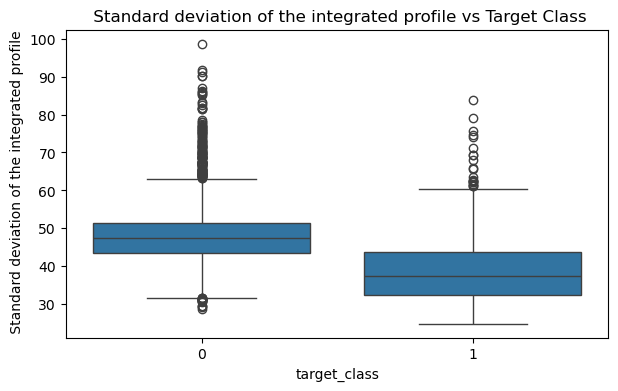

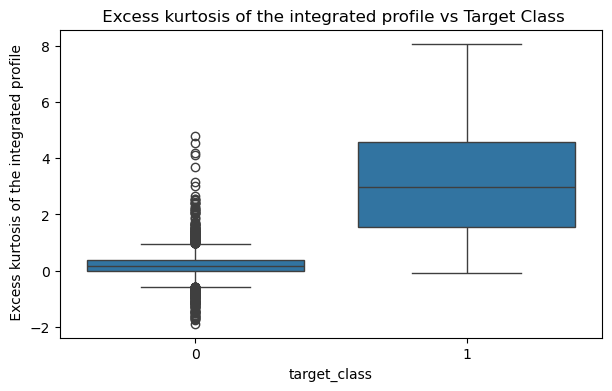

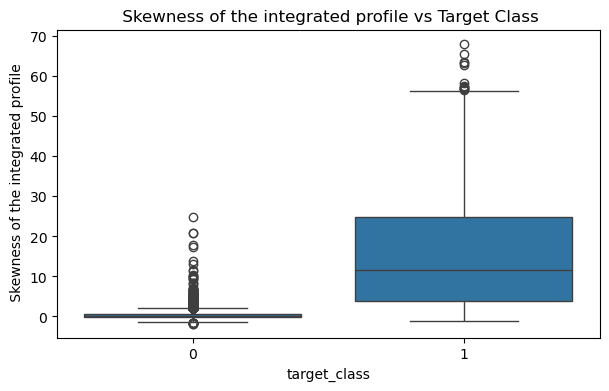

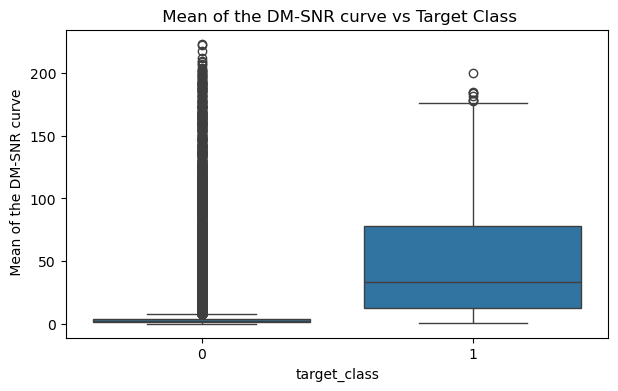

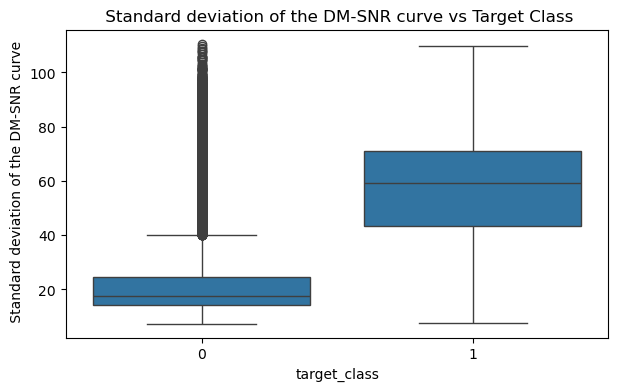

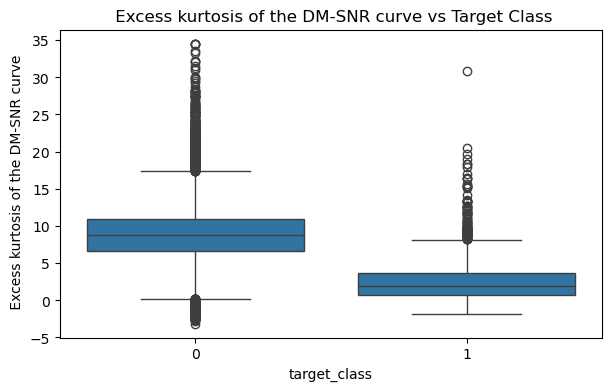

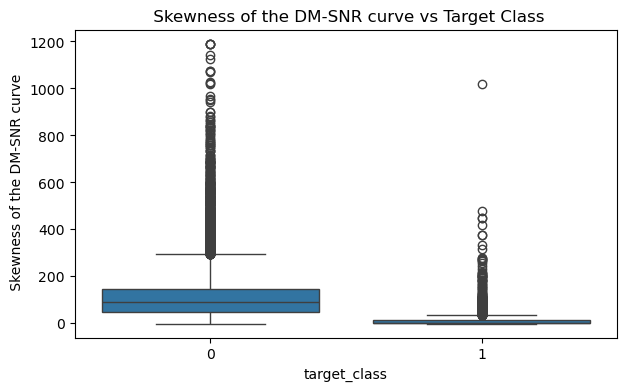

In [16]:
for feature in feature_columns:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(
        x=target_column,
        y=feature,
        data=data
    )
    
    plt.title(f"{feature} vs Target Class")
    plt.show()

# Outlier Analysis

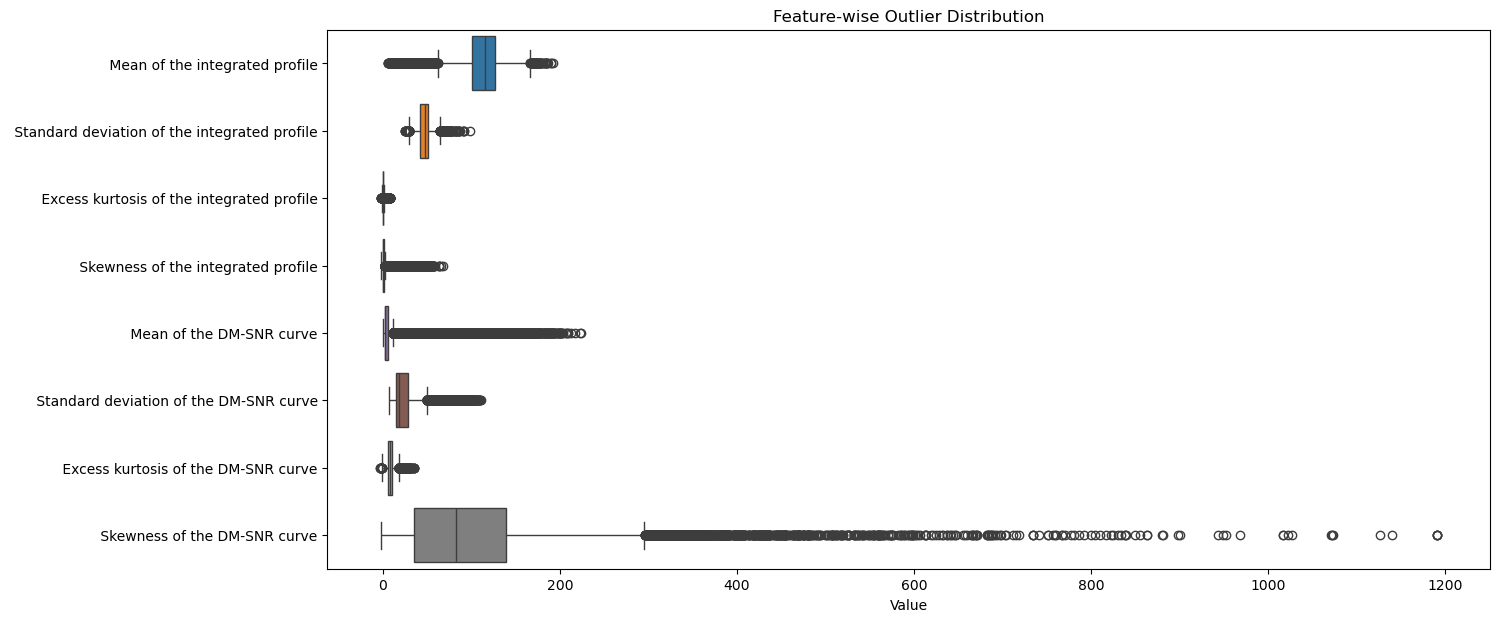

In [18]:
plt.figure(figsize=(15, 7))

sns.boxplot(
    data=data[feature_columns],
    orient="h"
)

plt.title("Feature-wise Outlier Distribution")
plt.xlabel("Value")
plt.show()

# Data Prep 

In [19]:
X = data.drop(columns=[target_column])
y = data[target_column]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (17898, 8)
Target vector shape: (17898,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 14318
Testing samples: 3580

Training class distribution:
target_class
0    13007
1     1311
Name: count, dtype: int64

Testing class distribution:
target_class
0    3252
1     328
Name: count, dtype: int64


# Feature Scaling

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# Linear SVM

In [22]:
linear_svm = SVC(
    kernel="linear",
    C=1.0
)

linear_svm.fit(
    X_train_scaled,
    y_train
)

y_pred_linear = linear_svm.predict(X_test_scaled)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


In [23]:
linear_accuracy = accuracy_score(y_test, y_pred_linear)
linear_precision = precision_score(y_test, y_pred_linear)
linear_recall = recall_score(y_test, y_pred_linear)
linear_f1 = f1_score(y_test, y_pred_linear)

print("Linear SVM Performance")
print("----------------------")
print("Accuracy :", round(linear_accuracy * 100, 2), "%")
print("Precision:", round(linear_precision, 4))
print("Recall   :", round(linear_recall, 4))
print("F1-Score :", round(linear_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear))

Linear SVM Performance
----------------------
Accuracy : 97.99 %
Precision: 0.9571
Recall   : 0.8171
F1-Score : 0.8816

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3252
           1       0.96      0.82      0.88       328

    accuracy                           0.98      3580
   macro avg       0.97      0.91      0.94      3580
weighted avg       0.98      0.98      0.98      3580



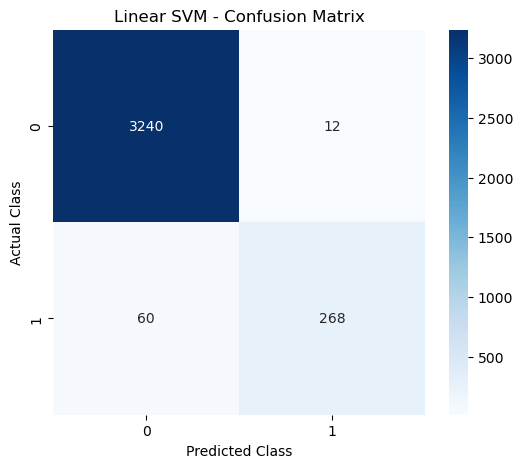

In [24]:
cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_linear,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Linear SVM - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## Non-Linear SVM
### RBF Kernel

In [26]:
rbf_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

rbf_svm.fit(
    X_train_scaled,
    y_train
)

y_pred_rbf = rbf_svm.predict(X_test_scaled)

print("RBF SVM trained successfully.")

RBF SVM trained successfully.


In [27]:
rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
rbf_precision = precision_score(y_test, y_pred_rbf)
rbf_recall = recall_score(y_test, y_pred_rbf)
rbf_f1 = f1_score(y_test, y_pred_rbf)

print("RBF SVM Performance")
print("-------------------")
print("Accuracy :", round(rbf_accuracy * 100, 2), "%")
print("Precision:", round(rbf_precision, 4))
print("Recall   :", round(rbf_recall, 4))
print("F1-Score :", round(rbf_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf))

RBF SVM Performance
-------------------
Accuracy : 98.07 %
Precision: 0.9481
Recall   : 0.8354
F1-Score : 0.8882

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3252
           1       0.95      0.84      0.89       328

    accuracy                           0.98      3580
   macro avg       0.97      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



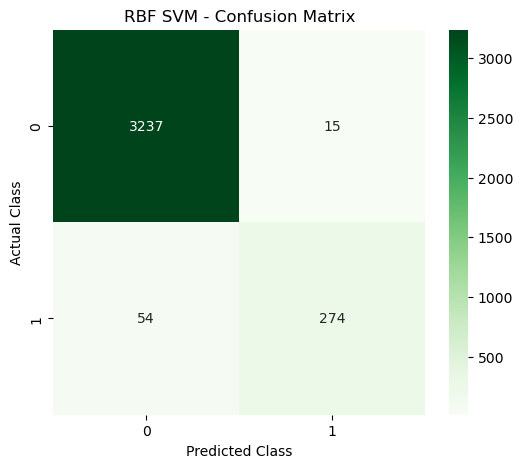

In [28]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rbf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("RBF SVM - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## Polynomial Kernel SVM

In [29]:
poly_svm = SVC(
    kernel="poly",
    degree=3,
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

poly_svm.fit(
    X_train_scaled,
    y_train
)

y_pred_poly = poly_svm.predict(X_test_scaled)

print("Polynomial SVM trained successfully.")

Polynomial SVM trained successfully.


In [30]:
poly_accuracy = accuracy_score(y_test, y_pred_poly)
poly_precision = precision_score(y_test, y_pred_poly)
poly_recall = recall_score(y_test, y_pred_poly)
poly_f1 = f1_score(y_test, y_pred_poly)

print("Polynomial SVM Performance")
print("-------------------------")
print("Accuracy :", round(poly_accuracy * 100, 2), "%")
print("Precision:", round(poly_precision, 4))
print("Recall   :", round(poly_recall, 4))
print("F1-Score :", round(poly_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_poly))

Polynomial SVM Performance
-------------------------
Accuracy : 97.79 %
Precision: 0.9399
Recall   : 0.811
F1-Score : 0.8707

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3252
           1       0.94      0.81      0.87       328

    accuracy                           0.98      3580
   macro avg       0.96      0.90      0.93      3580
weighted avg       0.98      0.98      0.98      3580



## Kernel Performance Comparison

In [31]:
kernel_results = pd.DataFrame({
    "Kernel": [
        "Linear",
        "RBF",
        "Polynomial"
    ],
    "Accuracy": [
        linear_accuracy,
        rbf_accuracy,
        poly_accuracy
    ],
    "Precision": [
        linear_precision,
        rbf_precision,
        poly_precision
    ],
    "Recall": [
        linear_recall,
        rbf_recall,
        poly_recall
    ],
    "F1-Score": [
        linear_f1,
        rbf_f1,
        poly_f1
    ]
})

display(
    kernel_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

,Kernel,Accuracy,Precision,Recall,F1-Score
0,Linear,0.9799,0.9571,0.8171,0.8816
1,RBF,0.9807,0.9481,0.8354,0.8882
2,Polynomial,0.9779,0.9399,0.8110,0.8707


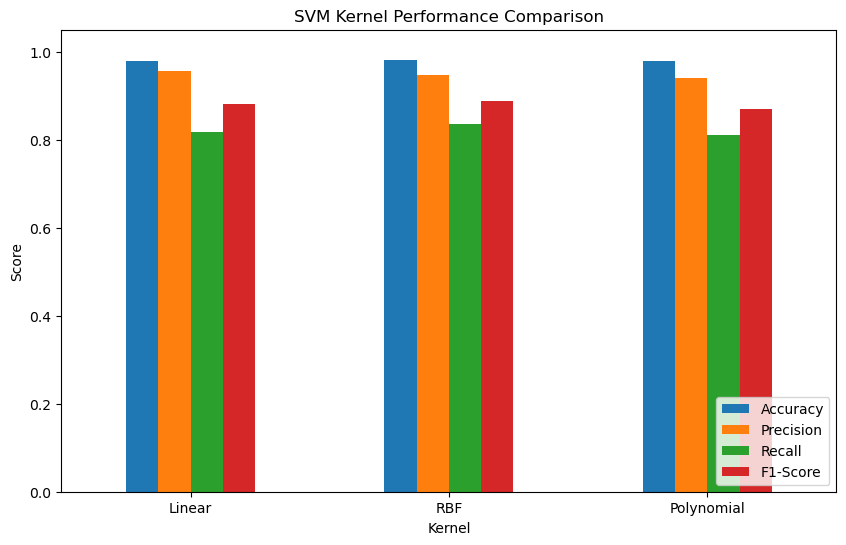

In [32]:
kernel_results_plot = kernel_results.set_index("Kernel")

kernel_results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("SVM Kernel Performance Comparison")
plt.xlabel("Kernel")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## Hyperparameter Tuning
### GridSearchCV

In [33]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        probability=True,
        random_state=42
    ))
])

param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1, 10, 100]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1, 10],
        "svm__degree": [2, 3, 4],
        "svm__gamma": ["scale", 0.01, 0.1]
    }
]

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 51 candidates, totalling 255 fits
Hyperparameter tuning completed.


In [34]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'svm__C': 100, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}

Best Cross-Validation F1-Score:
0.8814


## Cross-Validation Results

In [35]:
cv_results = pd.DataFrame(grid_search.cv_results_)

selected_columns = [
    "param_svm__kernel",
    "param_svm__C",
    "param_svm__gamma",
    "param_svm__degree",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

available_columns = [
    column for column in selected_columns
    if column in cv_results.columns
]

display(
    cv_results[available_columns]
    .sort_values("rank_test_score")
    .head(15)
)

,param_svm__kernel,param_svm__C,param_svm__gamma,param_svm__degree,mean_test_score,std_test_score,rank_test_score
22,rbf,100.0,0.1,NaN,0.881410,0.012372,1
17,rbf,10.0,0.1,NaN,0.880003,0.016668,2
19,rbf,100.0,scale,NaN,0.879980,0.015013,3
21,rbf,100.0,0.01,NaN,0.879904,0.018378,4
14,rbf,10.0,scale,NaN,0.879119,0.015008,5
2,linear,10.0,NaN,NaN,0.878387,0.023379,6
3,linear,100.0,NaN,NaN,0.878037,0.024015,7
16,rbf,10.0,0.01,NaN,0.877798,0.019116,8
20,rbf,100.0,0.001,NaN,0.877078,0.020930,9
1,linear,1.0,NaN,NaN,0.876840,0.023411,10


## Final Tuned SVM

In [36]:
best_svm = grid_search.best_estimator_

y_pred_best = best_svm.predict(X_test)

print("Final tuned SVM prediction completed.")

Final tuned SVM prediction completed.


## Final Model Evaluation

In [37]:
best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best)
best_recall = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)

print("Final Tuned SVM Performance")
print("---------------------------")
print("Accuracy :", round(best_accuracy * 100, 2), "%")
print("Precision:", round(best_precision, 4))
print("Recall   :", round(best_recall, 4))
print("F1-Score :", round(best_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Final Tuned SVM Performance
---------------------------
Accuracy : 98.07 %
Precision: 0.9331
Recall   : 0.8506
F1-Score : 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.93      0.85      0.89       328

    accuracy                           0.98      3580
   macro avg       0.96      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



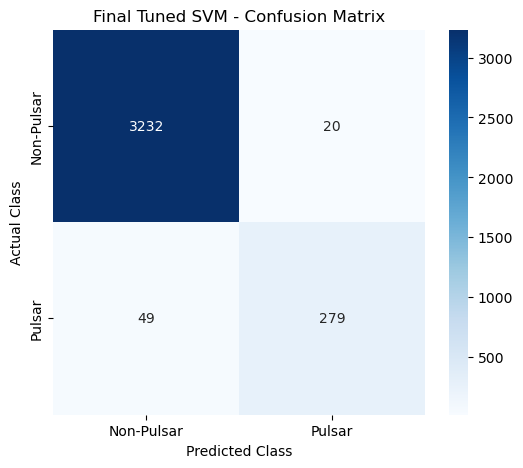

In [38]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Pulsar", "Pulsar"],
    yticklabels=["Non-Pulsar", "Pulsar"]
)

plt.title("Final Tuned SVM - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## ROC Curve and AUC

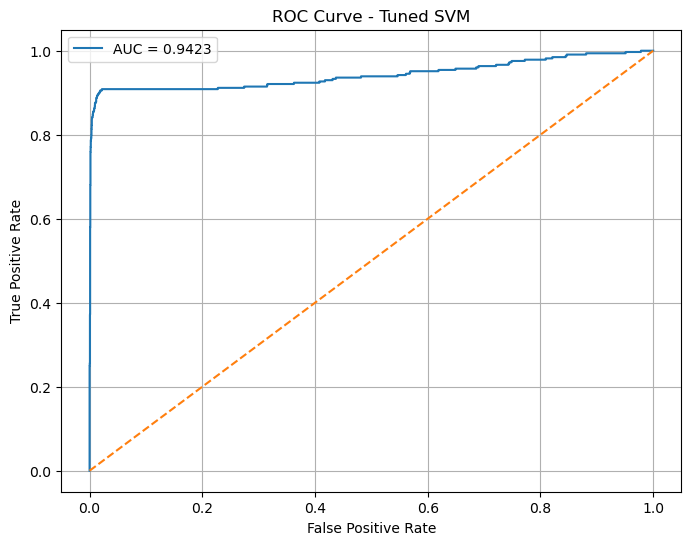

ROC-AUC Score: 0.9423


In [39]:
y_probability = best_svm.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned SVM")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC Score:", round(roc_auc, 4))

## Precision Recall Curve

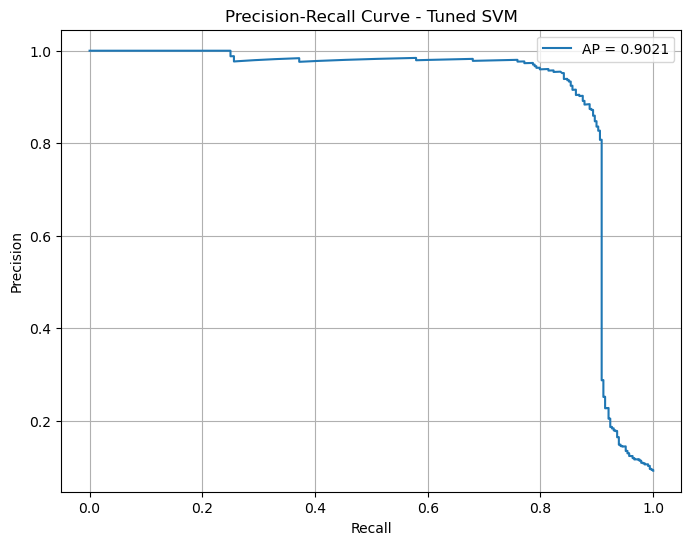

Average Precision Score: 0.9021


In [40]:
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_probability
)

average_precision = average_precision_score(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"AP = {average_precision:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned SVM")
plt.legend()
plt.grid()
plt.show()

print("Average Precision Score:", round(average_precision, 4))

## PCA Visualization

In [41]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    StandardScaler().fit_transform(X)
)

pca_data = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_data[target_column] = y.values

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal variance explained:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Explained variance ratio:
[0.51675584 0.26807564]

Total variance explained: 78.48 %


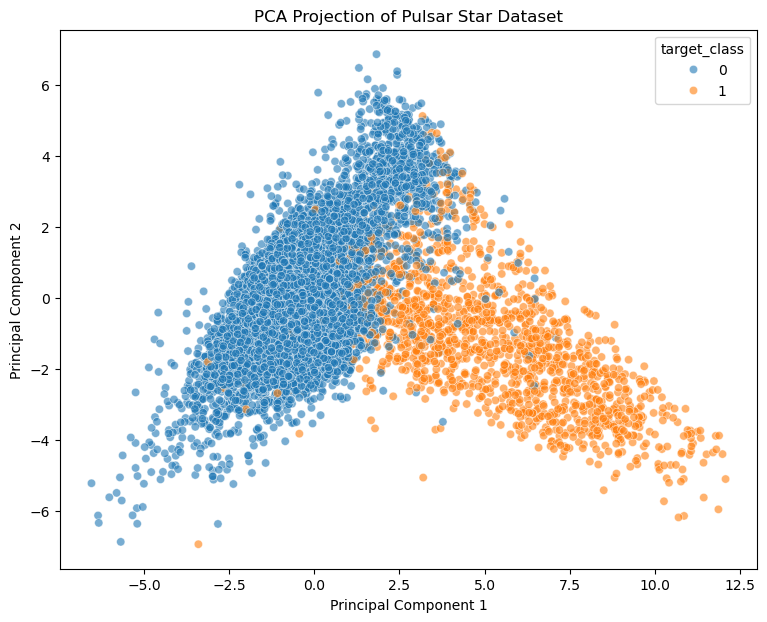

In [42]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_data,
    x="PC1",
    y="PC2",
    hue=target_column,
    alpha=0.6
)

plt.title("PCA Projection of Pulsar Star Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Support Vector Analysis

In [43]:
final_svm_model = best_svm.named_steps["svm"]

print("Kernel:", final_svm_model.kernel)
print("Number of support vectors:", len(final_svm_model.support_))

print("\nSupport vectors per class:")
print(final_svm_model.n_support_)

print("\nTotal support vectors:")
print(final_svm_model.n_support_.sum())

Kernel: rbf
Number of support vectors: 733

Support vectors per class:
[385 348]

Total support vectors:
733


In [44]:
support_vector_percentage = (
    final_svm_model.n_support_.sum()
    / len(X_train)
) * 100

print(
    "Support vectors as percentage of training data:",
    round(support_vector_percentage, 2),
    "%"
)

Support vectors as percentage of training data: 5.12 %


## New Smaple Prediction

In [45]:
new_sample = pd.DataFrame(
    [[
        140.5625,
        55.683782,
        -0.234571,
        -0.699648,
        3.199833,
        19.110426,
        7.975532,
        74.242225
    ]],
    columns=feature_columns
)

prediction = best_svm.predict(new_sample)
prediction_probability = best_svm.predict_proba(new_sample)[0]

print("Predicted Class:", prediction[0])

print("\nPrediction Probabilities:")
for class_label, probability in zip(
    best_svm.classes_,
    prediction_probability
):
    print(
        f"Class {class_label}: {probability:.4f}"
    )

Predicted Class: 0

Prediction Probabilities:
Class 0: 0.9885
Class 1: 0.0115


## Model Comparison

In [46]:
final_comparison = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "RBF SVM",
        "Polynomial SVM",
        "Tuned SVM"
    ],
    "Accuracy": [
        linear_accuracy,
        rbf_accuracy,
        poly_accuracy,
        best_accuracy
    ],
    "Precision": [
        linear_precision,
        rbf_precision,
        poly_precision,
        best_precision
    ],
    "Recall": [
        linear_recall,
        rbf_recall,
        poly_recall,
        best_recall
    ],
    "F1-Score": [
        linear_f1,
        rbf_f1,
        poly_f1,
        best_f1
    ]
})

display(
    final_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.9799,0.9571,0.8171,0.8816
1,RBF SVM,0.9807,0.9481,0.8354,0.8882
2,Polynomial SVM,0.9779,0.9399,0.8110,0.8707
3,Tuned SVM,0.9807,0.9331,0.8506,0.8900


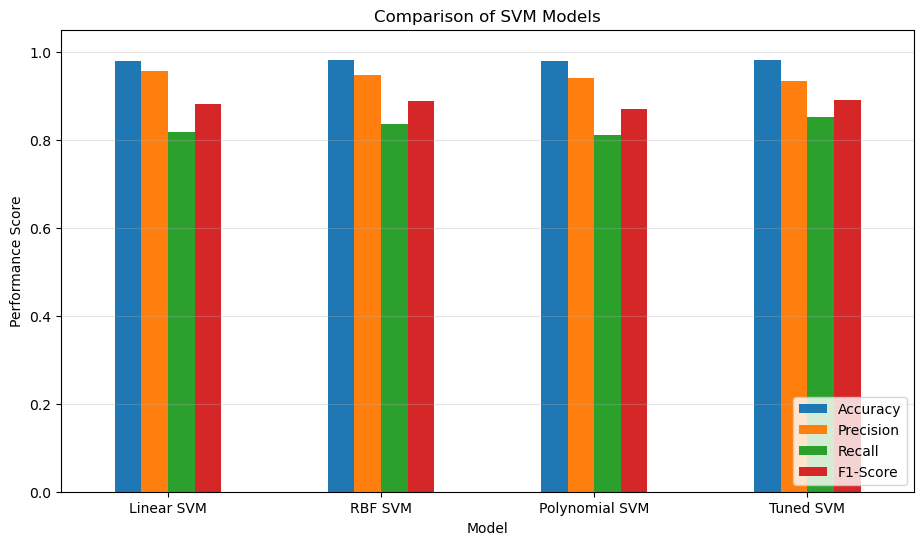

In [47]:
final_comparison_plot = final_comparison.set_index("Model")

final_comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparison of SVM Models")
plt.xlabel("Model")
plt.ylabel("Performance Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Best Model

In [48]:
best_model_index = final_comparison["F1-Score"].idxmax()

print(
    "Best model based on F1-Score:",
    final_comparison.loc[best_model_index, "Model"]
)

print(
    "Best F1-Score:",
    round(
        final_comparison.loc[best_model_index, "F1-Score"],
        4
    )
)

print(
    "Best Accuracy:",
    round(
        final_comparison.loc[best_model_index, "Accuracy"] * 100,
        2
    ),
    "%"
)

Best model based on F1-Score: Tuned SVM
Best F1-Score: 0.89
Best Accuracy: 98.07 %


## Conclusion

The Support Vector Machine algorithm was successfully implemented on the Pulsar Star dataset for binary classification.

The dataset was analyzed using exploratory data analysis, missing-value checking, duplicate detection, class-distribution analysis, feature distributions, correlation analysis, and outlier visualization. The numerical features were standardized before training the SVM models.

Linear, RBF, and Polynomial kernel-based SVM classifiers were implemented and compared using accuracy, precision, recall, and F1-score. The RBF kernel was able to model non-linear relationships between the features and target classes.

Hyperparameter optimization was further performed using GridSearchCV with stratified cross-validation. The regularization parameter C, kernel coefficient gamma, and polynomial degree were optimized to obtain a better-performing model.

The final model was evaluated using a confusion matrix, classification report, ROC-AUC score, and Precision-Recall curve. PCA was also used to visualize the dataset in a two-dimensional feature space, and the number of support vectors was analyzed to understand their role in the SVM decision boundary.

Thus, the experiment demonstrates the practical application of SVM for classification and the importance of feature scaling, kernel selection, and hyperparameter optimization in obtaining an effective machine learning model.